In [1]:
import json
from collections import Counter
import pandas as pd

In [2]:
with open("test_results/biomedbert_test_result.json", "r", encoding="utf-8") as f:
    biomedbert_corpus = json.load(f)
print(biomedbert_corpus[0])

{'sample_index': 0, 'text_stream': [{'token': 'non', 'true': ['T131'], 'pred': ['T109']}, {'token': 'diet', 'true': ['T131'], 'pred': ['T109']}, {'token': 'inhibits', 'true': ['T052'], 'pred': ['T052']}, {'token': 'apoptosis', 'true': ['T043'], 'pred': ['T043']}, {'token': 'induced', 'true': ['T169'], 'pred': ['T169']}, {'token': 'in', 'true': ['O'], 'pred': ['O']}, {'token': 'pc12', 'true': ['T025'], 'pred': ['T025']}, {'token': 'cells', 'true': ['T025'], 'pred': ['T025']}, {'token': 'non', 'true': ['T131'], 'pred': ['T109']}, {'token': 'and', 'true': ['O'], 'pred': ['O']}, {'token': 'short', 'true': ['T131'], 'pred': ['T109']}, {'token': 'chain', 'true': ['T131'], 'pred': ['T109']}, {'token': 'non', 'true': ['T131'], 'pred': ['T109']}, {'token': 'eth', 'true': ['T131'], 'pred': ['T109']}, {'token': 'such', 'true': ['O'], 'pred': ['O']}, {'token': 'as', 'true': ['O'], 'pred': ['O']}, {'token': 'np', 'true': ['T131'], 'pred': ['T109']}, {'token': 'eo', 'true': ['T131'], 'pred': ['T109'

### Functions for later analysis

In [ ]:
def analyze_exact_tag_combination(corpus, target_tags):
    """
    Filters the corpus for tokens where the true labels are EXACTLY 
    the combination specified in 'target_tags' (order-independent).
    
    Parameters:
    - corpus: The qualitative_corpus list of dictionaries.
    - target_tags: A list of strings, e.g., ["T131"] or ["T131", "T024"]
    """
    # Ensure target_tags is a list and sort it for reliable matching
    if isinstance(target_tags, str):
        target_tags = [target_tags]
    target_tags_sorted = sorted(target_tags)
    target_tags_str = ", ".join(target_tags_sorted)
    
    prediction_counts = Counter()
    matched_examples = []
    
    # Scan through the corpus
    for sample in corpus:
        for token_info in sample["text_stream"]:
            current_true_sorted = sorted(token_info["true"])
            
            if current_true_sorted == target_tags_sorted:
                pred_combo = ", ".join(sorted(token_info["pred"])) if token_info["pred"] else "O"
                prediction_counts[pred_combo] += 1
                
                matched_examples.append({
                    "token": token_info["token"],
                    "gold tag": target_tags,
                    "predicted": pred_combo,
                    "sample_idx": sample["sample_index"]
                })
                
    total_matches = sum(prediction_counts.values())
    
    if total_matches == 0:
        print(f"Empty for tag: [{target_tags_str}]")
        return None, []
        
  
    df_summary = pd.DataFrame(prediction_counts.items(), columns=["Predicted Combination", "Count"])
    df_summary = df_summary.sort_values(by="Count", ascending=False).reset_index(drop=True)
    df_summary["Percentage"] = ((df_summary["Count"] / total_matches) * 100).round(2).astype(str) + "%"
    
    print(f"Gold Target: [{target_tags_str}] (Total Occurrences: {total_matches})")
    return df_summary, matched_examples

In [ ]:
from collections import defaultdict
import pandas as pd

# Look at each individual tags performance with metrics precision, recall and F1-score. TP, FN, FP are also included aswell as the number of times the tags occured.
def analyze_individual_tag_performance(corpus):
    """
    Analyzes the model's prediction performance for every unique tag 
    present in the corpus across all tokens.
    
    Parameters:
    - corpus: The qualitative_corpus list of dictionaries.
    """
    # Trackers for true positives, false positives, and false negatives per tag
    # tp: tag was in true and in pred
    # fp: tag was in pred but NOT in true
    # fn: tag was in true but NOT in pred
    tp_counts = defaultdict(int)
    fp_counts = defaultdict(int)
    fn_counts = defaultdict(int)
    gold_counts = defaultdict(int)
    
    # Unique set of all tags seen in either ground truth or predictions
    all_tags = set()

    # Scan through the corpus
    for sample in corpus:
        for token_info in sample["text_stream"]:
            # Standardize inputs to sets for easy comparison, ignoring empty/O tags
            true_tags = set(token_info["true"]) if token_info["true"] else set()
            pred_tags = set(token_info["pred"]) if token_info["pred"] else set()
            
            all_tags.update(true_tags)
            all_tags.update(pred_tags)
            
            # Update gold total counts
            for t in true_tags:
                gold_counts[t] += 1
                
            # Evaluate predictions against ground truth
            for tag in true_tags | pred_tags:
                if tag in true_tags and tag in pred_tags:
                    tp_counts[tag] += 1
                elif tag in pred_tags and tag not in true_tags:
                    fp_counts[tag] += 1
                elif tag in true_tags and tag not in pred_tags:
                    fn_counts[tag] += 1

    if not all_tags:
        print("No tags found in the corpus.")
        return None

    # Build the summary data
    report_data = []
    for tag in sorted(all_tags):
        tp = tp_counts[tag]
        fp = fp_counts[tag]
        fn = fn_counts[tag]
        total_gold = gold_counts[tag]
        
        # Calculate percentages safely to avoid DivisionByZero
        precision = (tp / (tp + fp)) if (tp + fp) > 0 else 0.0
        recall = (tp / (tp + fn)) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        
        report_data.append({
            "Tag": tag,
            "Gold Occurrences": total_gold,
            "True Postive)": tp,
            "False Negatives": fn,
            "False Positive": fp,
            "Precision": f"{round(precision * 100, 2)}%",
            "Recall": f"{round(recall * 100, 2)}%",
            "F1-Score": round(f1, 4)
        })

    # Convert to DataFrame and sort by the most frequent tags
    df_performance = pd.DataFrame(report_data)
    df_performance = df_performance.sort_values(by="Gold Occurrences", ascending=False).reset_index(drop=True)
    
    return df_performance

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function used to plot recall over precision with metadata such a color showing F1-score and size showing the frequency
def plot_precision_recall_tradeoff(df_performance):
    # Clean the percentage strings back to floats for plotting
    df = df_performance.copy()
    df['Precision'] = df['Precision'].str.rstrip('%').astype(float)
    df['Recall'] = df['Recall'].str.rstrip('%').astype(float)
    
    plt.figure(figsize=(15, 10.5))
    sns.set_theme(style="whitegrid")
    
    # 1. Draw the scatter plot
    ax = sns.scatterplot(
        data=df, x='Recall', y='Precision', 
        size='Gold Occurrences', sizes=(40, 400), hue='F1-Score', palette='viridis'
    )
    
    # 2. Label the individual data points with the Tag names
    for i in range(df.shape[0]):
        plt.text(df['Recall'][i] + 1, df['Precision'][i], df['Tag'][i], 
                 horizontalalignment='left', size='small', color='black', weight='semibold')
        
    plt.title('Tag Performance Landscape (Precision vs. Recall) [O tag excluded]', fontsize=14, pad=15)
    plt.xlabel('Recall (%)', fontsize=11)
    plt.ylabel('Precision (%)', fontsize=11)
    plt.xlim(-5, 105)
    plt.ylim(-5, 105)
    plt.axline((0, 0), slope=1, linestyle="--", color="gray", alpha=0.5) 
    
    # 3. Extract the clean rendering handles and labels generated by Seaborn
    handles, labels = ax.get_legend_handles_labels()
    
    # 4. Rebuild the labels manually, applying heavy weight to the header categories
    new_labels = []
    for label in labels:
        if label == "F1-Score":
            new_labels.append(r"$\bf{F1\text{-}Score}$") # LaTeX bold math format for matplotlib
        elif label == "Gold Occurrences":
            new_labels.append(r"$\bf{Gold\ Occurrences}$")
        else:
            new_labels.append(label) # Keep numerical rows normal weight
            
    # Re-apply our newly customized label list back to the chart frame
    ax.legend(handles, new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
            
    plt.tight_layout()
    plt.show()

In [ ]:
from collections import defaultdict
import pandas as pd

# This function outputs a dataframe with information about every token. It includes the five most frequent tags for every word and explain how many times it predicted that,
# aswell saying when it got it wrong. 
def analyze_token_top_predictions_with_counts(corpus):
    """
    Analyzes prediction accuracy down to the specific word/token level.
    Shows the top 5 most frequently predicted tags, raw matching counts,
    and how often that tag actually occurred in the ground truth for that word.
    
    Parameters:
    - corpus: The qualitative_corpus list of dictionaries.
    """
    # Track statistics per token and tag combination
    # token_stats[token][tag] = {"total_guesses": X, "correct_guesses": Y, "gold_occurrences": Z}
    token_stats = defaultdict(lambda: defaultdict(lambda: {"total_guesses": 0, "correct_guesses": 0, "gold_occurrences": 0}))
    token_appearances = defaultdict(int)

    # 1. Gather all raw counts from the corpus
    for sample in corpus:
        for token_info in sample["text_stream"]:
            token = token_info["token"].strip()
            if not token:
                continue
                
            token_appearances[token] += 1
            
            true_tags = set(token_info["true"]) if token_info["true"] else set()
            pred_tags = set(token_info["pred"]) if token_info["pred"] else set()
            
            # Record every time a tag *actually* should have been predicted for this word
            for t_tag in true_tags:
                token_stats[token][t_tag]["gold_occurrences"] += 1
            
            # Record what the model *actually* predicted
            for p_tag in pred_tags:
                token_stats[token][p_tag]["total_guesses"] += 1
                if p_tag in true_tags:
                    token_stats[token][p_tag]["correct_guesses"] += 1

    # 2. Process and extract top 5 predicted tags for each token
    rows = []
    for token, tags_dict in token_stats.items():
        # Sort tags by how often the model predicted them
        sorted_preds = sorted(
            tags_dict.items(), 
            key=lambda item: item[1]["total_guesses"], 
            reverse=True
        )
        
        # Pull out the top 5
        top_5_preds = sorted_preds[:5]
        
        for rank, (tag, counts) in enumerate(top_5_preds, start=1):
            total_g = counts["total_guesses"]
            correct_g = counts["correct_guesses"]
            gold_occ = counts["gold_occurrences"]
            
            # Calculate accuracy percentage safely
            accuracy_pct = (correct_g / total_g) * 100 if total_g > 0 else 0.0
            
            rows.append({
                "Token (Word)": token,
                "Total Word Instances": token_appearances[token],
                "Rank": f"#{rank}",
                "Predicted Tag": tag,
                "Times Predicted": total_g,
                "Correct Predictions": correct_g,
                "Actual Occurrences (Gold)": gold_occ,
                "Prediction Accuracy": f"{round(accuracy_pct, 2)}%"
            })

    # 3. Create and sort DataFrame
    df_token_analysis = pd.DataFrame(rows)
    df_token_analysis = df_token_analysis.sort_values(
        by=["Total Word Instances", "Token (Word)", "Rank"], 
        ascending=[False, True, True]
    ).reset_index(drop=True)
    
    return df_token_analysis

In [ ]:
from collections import defaultdict
import pandas as pd

# This functions creates a dataframe, where each word gets their own row to tell us precentage wise how much it got it totally correct, partially corroct or completely wrong.
# Partially correct is there when there are multiple tags to predict and it only guesses a part of the tags. Then it is partially correct. It also includes infomration if some
# word are frequent or rare based on a user-defined parameter. It also tries to get around capitilazed words and tells us how many versions there are shows us the varaints. 
def advanced_corpus_diagnostic(corpus, rare_word_threshold=3):
    """
    Advanced diagnostic tool to uncover hidden token-level patterns:
    - Identifies capitalization biases (e.g., 'Patient' vs 'patient').
    - Evaluates performance on Rare vs. Frequent words.
    - Captures Multi-label Partial Matches.
    """
    token_stats = defaultdict(lambda: {
        "appearances": 0,
        "exact_matches": 0,
        "partial_matches": 0,
        "total_failures": 0,
        "true_tags_seen": defaultdict(int),
        "pred_tags_seen": defaultdict(int),
        "cases_seen": set()
    })
    
    total_tokens_processed = 0

    # 1. Processing Loop
    for sample in corpus:
        for token_info in sample["text_stream"]:
            raw_token = token_info["token"].strip()
            if not raw_token:
                continue
                
            total_tokens_processed += 1
            
            # Use lowercase as the anchor to compare casing behaviors later
            anchor = raw_token.lower()
            token_stats[anchor]["appearances"] += 1
            token_stats[anchor]["cases_seen"].add(raw_token)
            
            true_set = set(token_info["true"]) if token_info["true"] else set()
            pred_set = set(token_info["pred"]) if token_info["pred"] else set()
            
            # Track tags individually for background reference
            for t in true_set: token_stats[anchor]["true_tags_seen"][t] += 1
            for p in pred_set: token_stats[anchor]["pred_tags_seen"][p] += 1
            
            # Match Evaluation Matrix
            if true_set == pred_set:
                token_stats[anchor]["exact_matches"] += 1
            elif true_set & pred_set: # There is an intersection (shared tags)
                token_stats[anchor]["partial_matches"] += 1
            else:
                token_stats[anchor]["total_failures"] += 1

    # 2. Compile Analytical Insights
    rows = []
    for anchor, stats in token_stats.items():
        total = stats["appearances"]
        exact_pct = (stats["exact_matches"] / total) * 100
        partial_pct = (stats["partial_matches"] / total) * 100
        fail_pct = (stats["total_failures"] / total) * 100
        
        # Determine frequency class
        freq_class = "Rare" if total <= rare_word_threshold else "Frequent"
        
        # Highlight casing discrepancies
        casing_variants = list(stats["cases_seen"])
        has_case_variance = "Yes" if len(casing_variants) > 1 else "No"
        
        rows.append({
            "Token Base": anchor,
            "Total Volume": total,
            "Frequency Class": freq_class,
            "Casing Variants": ", ".join(casing_variants),
            "Has Casing Variance": has_case_variance,
            "Exact Match %": f"{round(exact_pct, 1)}%",
            "Partial Match %": f"{round(partial_pct, 1)}%",
            "Complete Failure %": f"{round(fail_pct, 1)}%"
        })

    df_diagnostic = pd.DataFrame(rows)
    df_diagnostic = df_diagnostic.sort_values(by="Total Volume", ascending=False).reset_index(drop=True)
    return df_diagnostic

In [89]:
from collections import defaultdict
import pandas as pd

# Here you enter a gold tag to get information on all the different words that got that tag, what it predicted and how accurate was it.
def analyze_single_gold_tag_predictions(corpus, target_tag):
    """
    Filters the corpus for a specific gold tag and aggregates how every token 
    assigned that tag was predicted by the model.
    
    Parameters:
    - corpus: The qualitative_corpus list of dictionaries.
    - target_tag: String, the specific tag to audit (e.g., "T131")
    """
    # Group stats by the individual word/token
    # token_data[word] = {"correct": X, "total_instances_with_gold_tag": Y}
    token_data = defaultdict(lambda: {"correct": 0, "total": 0})
    
    # Track what else the model guessed when it got it wrong
    wrong_predictions_sample = defaultdict(list)

    # 1. Scan the text stream
    for sample in corpus:
        for token_info in sample["text_stream"]:
            true_tags = token_info["true"] if token_info["true"] else []
            pred_tags = token_info["pred"] if token_info["pred"] else []
            
            # We only care if this token instance has our target gold tag
            if target_tag in true_tags:
                token = token_info["token"].strip()
                if not token:
                    continue
                
                token_data[token]["total"] += 1
                
                # Check if the model correctly identified the target tag
                if target_tag in pred_tags:
                    token_data[token]["correct"] += 1
                else:
                    # Capture alternative predictions for context when it fails
                    alt_pred = ", ".join(sorted(pred_tags)) if pred_tags else "O"
                    wrong_predictions_sample[token].append(alt_pred)

    if not token_data:
        print(f"The tag '{target_tag}' was not found as a ground truth label anywhere in the corpus.")
        return None

    # 2. Compile into a DataFrame
    rows = []
    for token, counts in token_data.items():
        correct = counts["correct"]
        total = counts["total"]
        missed = total - correct
        
        accuracy_pct = (correct / total) * 100
        
        # Pull up to 3 unique example misclassifications for this word
        wrong_guesses = list(set(wrong_predictions_sample[token]))[:3]
        wrong_guesses_str = ", ".join(wrong_guesses) if wrong_guesses else "None (Always Correct)"
        
        rows.append({
            "Token (Word)": token,
            "Total Gold Instances": total,
            "Correctly Predicted": correct,
            "Missed Predictions": missed,
            "Accuracy %": f"{round(accuracy_pct, 2)}%",
            "Common Alternative Guesses": wrong_guesses_str
        })

    df_tag_audit = pd.DataFrame(rows)
    
    # Sort by the words that most frequently carry this tag
    df_tag_audit = df_tag_audit.sort_values(by="Total Gold Instances", ascending=False).reset_index(drop=True)
    
    print(f"--- Audit Report for Gold Tag: [{target_tag}] ---")
    return df_tag_audit

In [ ]:

summary, matched_examples = analyze_exact_tag_combination(biomedbert_corpus, "T109")

Gold Target: [T109] (Total Occurrences: 821)


### Analysis for the tags performance

In [ ]:
# Extracting the necessacry information
tag_performance = analyze_individual_tag_performance(biomedbert_corpus)
tag_performance

,Tag,Gold Occurrences,True Postive),False Negatives,False Positive,Precision,Recall,F1-Score
0,O,110221,101944,8277,31657,76.3%,92.49%,0.8362
1,T080,7458,3489,3969,2680,56.56%,46.78%,0.5121
2,T081,5520,3410,2110,2194,60.85%,61.78%,0.6131
3,T169,5169,1909,3260,2009,48.72%,36.93%,0.4202
4,T033,4882,1192,3690,1147,50.96%,24.42%,0.3301
...,...,...,...,...,...,...,...,...
120,T085,19,0,19,0,0.0%,0.0%,0.0000
121,T095,9,0,9,0,0.0%,0.0%,0.0000
122,T194,5,0,5,0,0.0%,0.0%,0.0000
123,T010,2,0,2,0,0.0%,0.0%,0.0000


In [ ]:
# Looking at how many tags gets a F1-score below or equal to 0.1
mask1 = tag_performance["F1-Score"] <= 0.1
print("The amount of tags that has f1-score lower or equal to 0.1 is:",tag_performance[mask1].shape[0])
mask2 = tag_performance["F1-Score"] > 0.1
print("The amount of tags that has f1-score above 0.1 is:",tag_performance[mask2].shape[0])

The amount of tags that has f1-score lower or equal to 0.1 is: 56
The amount of tags that has f1-score above 0.1 is: 69


In [ ]:
# Excluding the O tags for the next part so that it doesn't take to much attention away
tag_performance_without_O = tag_performance.drop(0)
tag_performance_without_O = tag_performance_without_O.reset_index(drop=True)

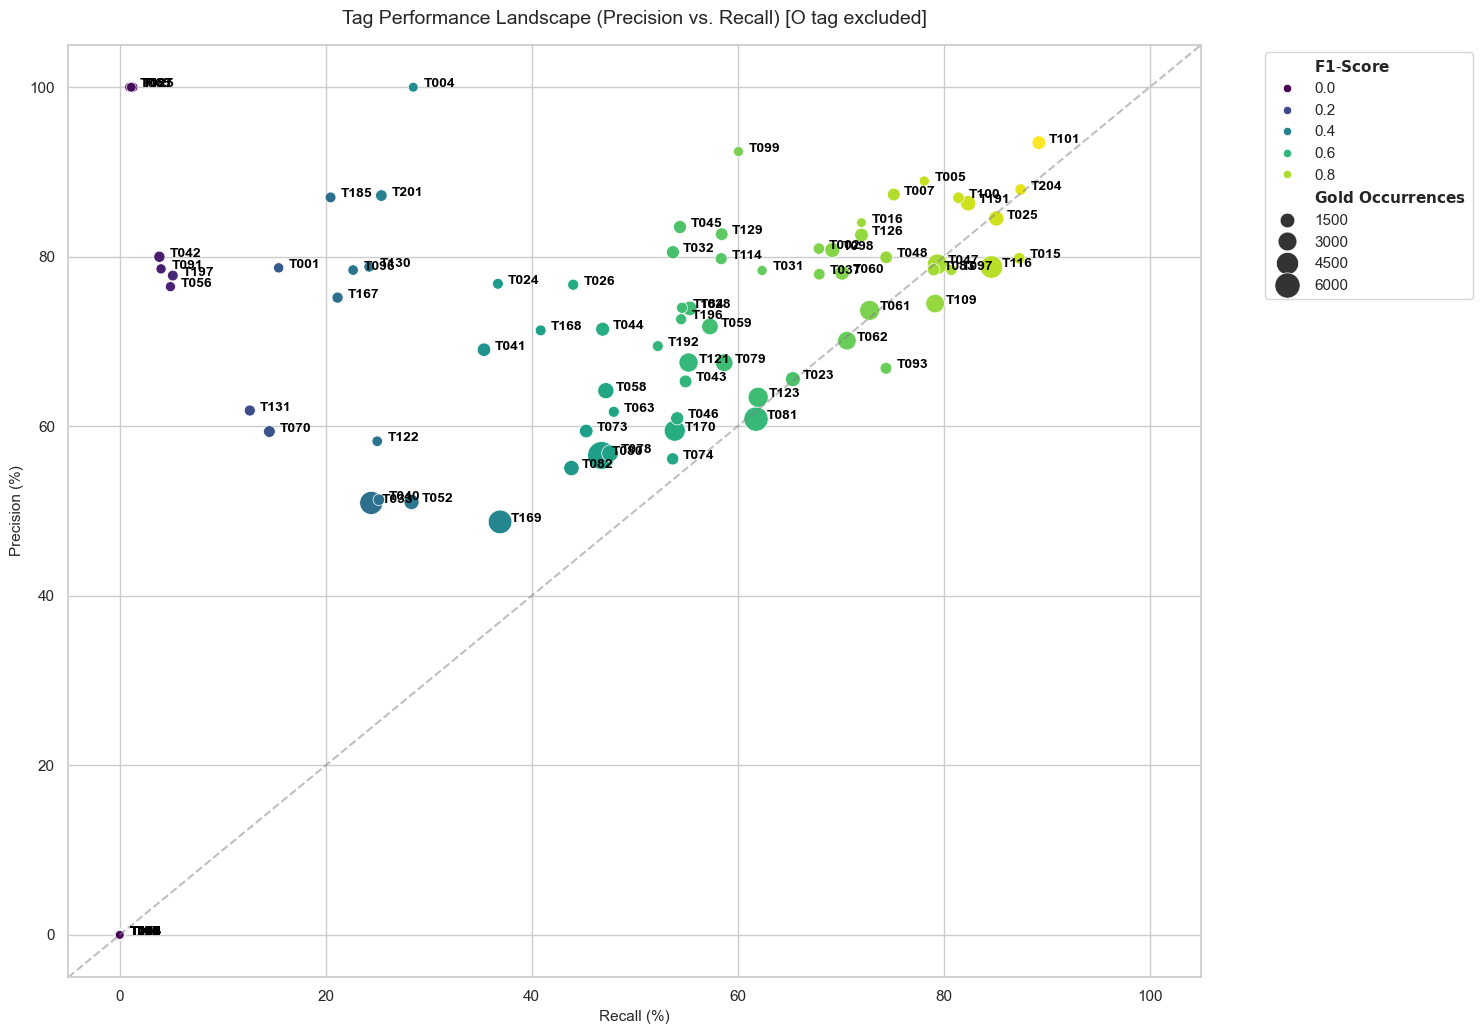

In [ ]:
# A plot with recall on x-axis and precision on y-axis to the relation or a general tendency in the tags.
plot_precision_recall_tradeoff(tag_performance_without_O)

<Axes: xlabel='F1-Score', ylabel='Count'>

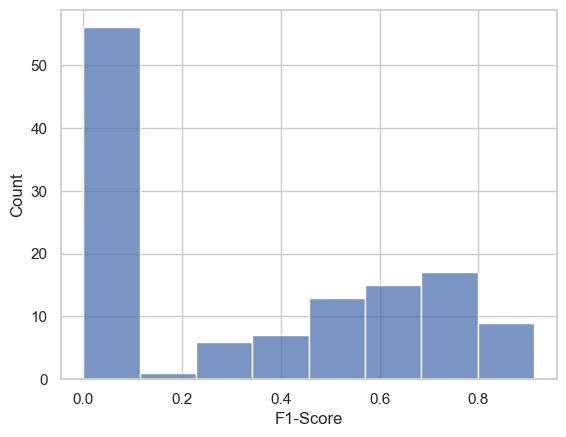

In [ ]:
# See the distribution of F1-scores
sns.histplot(tag_performance_without_O["F1-Score"])

In [90]:
# Looking further into what makes the tags have such a low F1-score
tag_performance[mask1].head()

,Tag,Gold Occurrences,True Postive),False Negatives,False Positive,Precision,Recall,F1-Score
39,T077,702,0,702,0,0.0%,0.0%,0.0000
49,T067,572,0,572,0,0.0%,0.0%,0.0000
51,T042,519,20,499,5,80.0%,3.85%,0.0735
63,T197,408,21,387,6,77.78%,5.15%,0.0966
66,T055,361,0,361,0,0.0%,0.0%,0.0000


In [92]:
analyze_single_gold_tag_predictions(biomedbert_corpus, "T042")

--- Audit Report for Gold Tag: [T042] ---


,Token (Word),Total Gold Instances,Correctly Predicted,Missed Predictions,Accuracy %,Common Alternative Guesses
0,function,19,0,19,0.0%,O
1,regeneration,16,1,15,6.25%,O
2,immune,16,1,15,6.25%,"O, T025"
3,of,11,0,11,0.0%,O
4,bone,11,0,11,0.0%,"O, T024"
...,...,...,...,...,...,...
205,smooth,1,0,1,0.0%,O
206,features,1,0,1,0.0%,T080
207,in,1,0,1,0.0%,O
208,increase,1,0,1,0.0%,T169


In [42]:
analyze_token_top_predictions_with_counts(biomedbert_corpus).head(10)

,Token (Word),Total Word Instances,Rank,Predicted Tag,Times Predicted,Correct Predictions,Actual Occurrences (Gold),Prediction Accuracy
0,the,9372,#1,O,9348,9261,9270,99.07%
1,the,9372,#2,T170,7,4,8,57.14%
2,the,9372,#3,T081,6,4,5,66.67%
3,the,9372,#4,T191,5,4,7,80.0%
4,the,9372,#5,T023,3,1,4,33.33%
5,of,8225,#1,O,7939,7516,7608,94.67%
6,of,8225,#2,T033,44,28,84,63.64%
7,of,8225,#3,T170,44,26,39,59.09%
8,of,8225,#4,T080,37,15,91,40.54%
9,of,8225,#5,T081,36,14,53,38.89%


In [27]:
advanced_corpus_diagnostic(biomedbert_corpus, 3)

,Token Base,Total Volume,Frequency Class,Casing Variants,Has Casing Variance,Exact Match %,Partial Match %,Complete Failure %
0,the,9372,Frequent,the,No,99.0%,0.0%,1.0%
1,of,8225,Frequent,of,No,93.3%,0.0%,6.7%
2,and,7613,Frequent,and,No,97.6%,0.0%,2.4%
3,in,5403,Frequent,in,No,98.1%,0.0%,1.9%
4,to,3836,Frequent,to,No,97.8%,0.0%,2.2%
...,...,...,...,...,...,...,...,...
13216,ig,1,Rare,ig,No,0.0%,0.0%,100.0%
13217,retr,1,Rare,retr,No,0.0%,0.0%,100.0%
13218,gle,1,Rare,gle,No,0.0%,0.0%,100.0%
13219,gout,1,Rare,gout,No,0.0%,0.0%,100.0%
